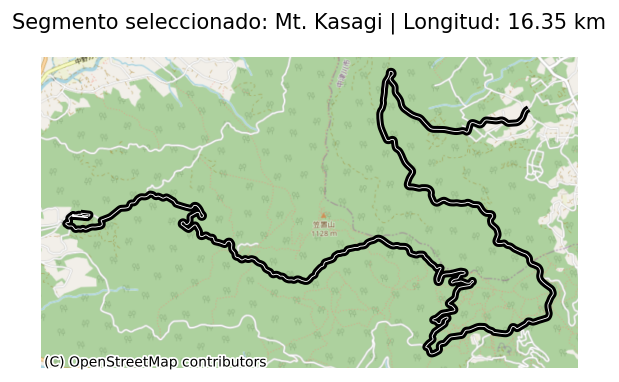

In [35]:
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout, QFileDialog, QComboBox, QListWidget
from PySide6.QtCore import Qt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
import sys
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import contextily as ctx
fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default

class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de la leyenda (Inicialmente deshabilitado)
        self.legend_button = QPushButton("📜 Crear Leyenda", self)
        self.legend_button.setEnabled(False)  # Deshabilitado hasta seleccionar un segmento
        self.legend_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.open_legend_creator)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def open_legend_creator(self):
        """ Abre la ventana de creación de leyenda """
        self.legend_window = LegendCreator(self.selected_segment, self.length_m)
        self.legend_window.show()

    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()



class LegendCreator(QWidget):
    def __init__(self, segment_name, length_m):
        super().__init__()
        self.segment_name = segment_name
        self.length_m = length_m
        self.initUI()
        


    def initUI(self):
        """ Inicializa la ventana de creación de leyenda """
        self.setWindowTitle("Crear Leyenda")
        self.setGeometry(200, 200, 500, 400)
        self.setStyleSheet("background-color: #f4f4f4; font-family: Arial; font-size: 14px;")

        layout = QVBoxLayout()

        # Etiqueta con el tramo seleccionado
        self.label = QLabel(f"📌 Segmento: {self.segment_name}\n📏 Longitud: {self.length_m/1000:.2f} km", self)
        self.label.setStyleSheet("font-weight: bold; background-color: white; padding: 10px; border-radius: 5px;")
        layout.addWidget(self.label)

        # Aquí podríamos agregar más elementos para la leyenda

        # Botón para cerrar
        self.close_button = QPushButton("🔙 Volver", self)
        self.close_button.setStyleSheet("background-color: #9370DB; color: #000000; padding: 8px; border-radius: 5px;")
        self.close_button.clicked.connect(self.close)
        layout.addWidget(self.close_button)

        self.setLayout(layout)
        

             
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()

# Primera Pestaña del Código OK

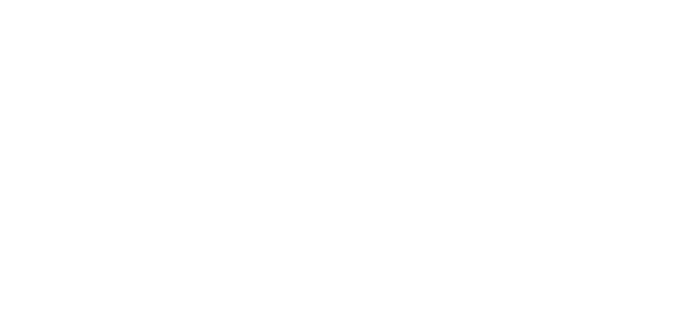

In [33]:
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout, QFileDialog, QComboBox, QListWidget
from PySide6.QtCore import Qt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
import sys
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import contextily as ctx
fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default

class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de leyenda
        self.legend_button = QPushButton("🖍️ Pasar a Creación de Leyenda", self)
        self.legend_button.setEnabled(False)
        self.legend_button.setStyleSheet("background-color: gray; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.go_to_legend_creation)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def go_to_legend_creation(self):
        """ Función para cambiar a la pantalla de creación de leyenda """
        print(f"Pasando a la creación de leyenda para: {self.selected_segment}")
        # Aquí podrías abrir una nueva ventana o cambiar el contenido del GUI
    
    
    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()
        
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()

AttributeError: 'FileSelector' object has no attribute 'open_legend_creator'

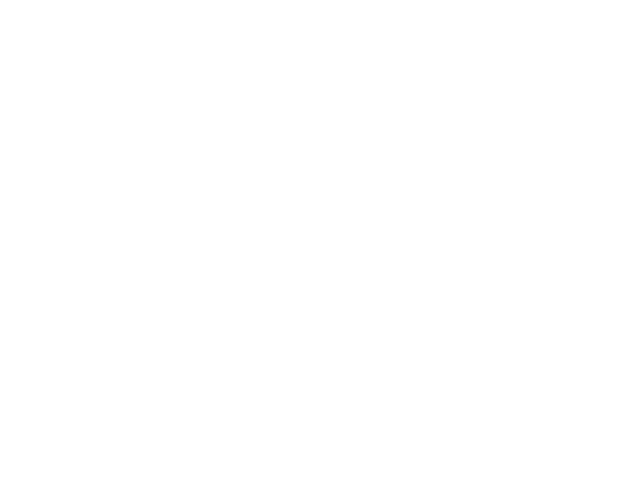

In [34]:


class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de la leyenda (Inicialmente deshabilitado)
        self.legend_button = QPushButton("📜 Crear Leyenda", self)
        self.legend_button.setEnabled(False)  # Deshabilitado hasta seleccionar un segmento
        self.legend_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.open_legend_creator)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def go_to_legend_creation(self):
        """ Función para cambiar a la pantalla de creación de leyenda """
        print(f"Pasando a la creación de leyenda para: {self.selected_segment}")
        # Aquí podrías abrir una nueva ventana o cambiar el contenido del GUI
    
    
    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()
        
        
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()